# TheNewRisetDurianWjbr_CRISPMD_v2
Linear notebook tanpa orchestrator dengan auto-save artifacts lengkap per run.


In [1]:
# [CRISP-DM: Business Understanding - Setup & Imports] [SAFE-RERUN]
import os, gc, json, time, uuid, random
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import calibration_curve

try:
    from scipy.stats import binomtest
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    from skimage.feature import hog
    from skimage.transform import resize
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('HAS_SCIPY:', HAS_SCIPY, '| HAS_SKIMAGE:', HAS_SKIMAGE)


TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
HAS_SCIPY: True | HAS_SKIMAGE: True


In [2]:
# [CRISP-DM: Data Understanding - Config & Paths] [SAFE-RERUN]
RUN_PROFILE = str(globals().get('RUN_PROFILE', 'full')).lower().strip()
SEED = int(globals().get('SEED', 42))
IMG_SIZE = tuple(globals().get('IMG_SIZE', (224, 224)))

# RAM-safe defaults for Colab T4
BATCH_SIZE = int(globals().get('BATCH_SIZE', 16 if RUN_PROFILE == 't4_safe' else 24))
USE_MIXED_PRECISION = bool(globals().get('USE_MIXED_PRECISION', RUN_PROFILE == 't4_safe'))

# Fair training budget
FAIR_TRAINING = True
if RUN_PROFILE == 't4_safe':
    HEAD_EPOCHS = int(globals().get('HEAD_EPOCHS', 4))
    FT_EPOCHS = int(globals().get('FT_EPOCHS', 2))
    EARLYSTOP_PATIENCE = int(globals().get('EARLYSTOP_PATIENCE', 2))
    STEPS_PER_EPOCH_CAP = int(globals().get('STEPS_PER_EPOCH_CAP', 80))
    VAL_STEPS_CAP = int(globals().get('VAL_STEPS_CAP', 30))
else:
    HEAD_EPOCHS = int(globals().get('HEAD_EPOCHS', 12))
    FT_EPOCHS = int(globals().get('FT_EPOCHS', 8))
    EARLYSTOP_PATIENCE = int(globals().get('EARLYSTOP_PATIENCE', 4))
    STEPS_PER_EPOCH_CAP = int(globals().get('STEPS_PER_EPOCH_CAP', 0))
    VAL_STEPS_CAP = int(globals().get('VAL_STEPS_CAP', 0))

LR_HEAD = float(globals().get('LR_HEAD', 8e-4))
LR_FT = float(globals().get('LR_FT', 8e-6))
WD_OPT = float(globals().get('WD_OPT', 1e-4))

# Artifacts root (prefer mounted drive if exists)
if 'ART_ROOT' in globals() and str(globals().get('ART_ROOT','')).strip():
    ART_ROOT = str(globals().get('ART_ROOT')).strip()
else:
    if os.path.isdir('/content/gdrive/MyDrive'):
        ART_ROOT = '/content/gdrive/MyDrive/Colab Notebooks/widuri/artifacts'
    elif os.path.isdir('/content/drive/MyDrive'):
        ART_ROOT = '/content/drive/MyDrive/Colab Notebooks/widuri/artifacts'
    else:
        ART_ROOT = './artifacts'

GLOBAL_LOG_PATH = os.path.join(ART_ROOT, 'lognilai.txt')
os.makedirs(ART_ROOT, exist_ok=True)

run_id = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '_' + uuid.uuid4().hex[:8]
RUN_DIR = os.path.join(ART_ROOT, 'runs', run_id)
DIRS = {
    'run': RUN_DIR,
    'figures': os.path.join(RUN_DIR, 'figures'),
    'tables': os.path.join(RUN_DIR, 'tables'),
    'models': os.path.join(RUN_DIR, 'models'),
    'predictions': os.path.join(RUN_DIR, 'predictions'),
    'best': os.path.join(RUN_DIR, 'best'),
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

if USE_MIXED_PRECISION:
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
    except Exception as e:
        print('WARN mixed precision:', e)

AUTOTUNE = tf.data.AUTOTUNE
print('RUN_PROFILE:', RUN_PROFILE)
print('RUN_DIR:', RUN_DIR)
print('BATCH_SIZE:', BATCH_SIZE, '| mixed_precision:', USE_MIXED_PRECISION)

# Method protocol artifact (reviewer-facing)
method_protocol = pd.DataFrame([
    {'key':'RUN_PROFILE','value':RUN_PROFILE},
    {'key':'BATCH_SIZE','value':BATCH_SIZE},
    {'key':'HEAD_EPOCHS','value':HEAD_EPOCHS},
    {'key':'FT_EPOCHS','value':FT_EPOCHS},
    {'key':'EARLYSTOP_PATIENCE','value':EARLYSTOP_PATIENCE},
    {'key':'STEPS_PER_EPOCH_CAP','value':STEPS_PER_EPOCH_CAP},
    {'key':'VAL_STEPS_CAP','value':VAL_STEPS_CAP},
    {'key':'LR_HEAD','value':LR_HEAD},
    {'key':'LR_FT','value':LR_FT},
    {'key':'WD_OPT','value':WD_OPT},
    {'key':'FAIR_TRAINING','value':FAIR_TRAINING},
    {'key':'USE_MIXED_PRECISION','value':USE_MIXED_PRECISION},
])
method_protocol.to_csv(os.path.join(DIRS['tables'], 'method_protocol.csv'), index=False)


RUN_PROFILE: full
RUN_DIR: ./artifacts/runs/20260308T024003Z_aaae6380
BATCH_SIZE: 24 | mixed_precision: False


In [3]:
# ==== WAJIB JALANKAN PALING AWAL DI COLAB (ROBUST MOUNT + DATA ROOT) ====
# Aman untuk rerun. Jika bukan Colab, sel ini tidak memaksa mount.
import os
from pathlib import Path

MOUNT_POINT = '/content/gdrive'
_IS_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in globals() else False

if _IS_COLAB:
    try:
        from google.colab import drive
        os.makedirs(MOUNT_POINT, exist_ok=True)
        # Hindari error "mountpoint already contains files"
        if os.path.isdir(MOUNT_POINT) and len(os.listdir(MOUNT_POINT)) > 0 and not os.path.ismount(MOUNT_POINT):
            for n in os.listdir(MOUNT_POINT):
                p = os.path.join(MOUNT_POINT, n)
                try:
                    if os.path.isdir(p):
                        import shutil
                        shutil.rmtree(p, ignore_errors=True)
                    else:
                        os.remove(p)
                except Exception:
                    pass
        drive.mount(MOUNT_POINT, force_remount=False)
        print('Drive mounted at', MOUNT_POINT)
    except Exception as e:
        print('WARN: mount failed, continue with existing filesystem ->', e)

# Auto detect DATA_ROOT with limited scan (efficient)
if 'DATA_ROOT' not in globals() or not str(globals().get('DATA_ROOT','')).strip():
    candidates = [
        '/content/gdrive/MyDrive/Colab Notebooks/widuri/dataset_duren',
        '/content/drive/MyDrive/Colab Notebooks/widuri/dataset_duren',
        '/content/gdrive/MyDrive/widuri/dataset_duren',
        '/content/drive/MyDrive/widuri/dataset_duren',
        '/content/dataset_duren',
        './dataset_duren',
    ]
    found = None
    for c in candidates:
        p = Path(c)
        if (p/'train').is_dir() and (p/'val').is_dir() and (p/'test').is_dir():
            found = str(p)
            break
    if found is None:
        # limited fallback scan
        roots = [Path('/content/gdrive/MyDrive/Colab Notebooks'), Path('/content/drive/MyDrive/Colab Notebooks'), Path('/content/gdrive/MyDrive'), Path('/content/drive/MyDrive')]
        for r in roots:
            if not r.exists():
                continue
            for d in r.rglob('dataset_duren'):
                if (d/'train').is_dir() and (d/'val').is_dir() and (d/'test').is_dir():
                    found = str(d)
                    break
            if found:
                break
    DATA_ROOT = found

print('DATA_ROOT =', DATA_ROOT)


Mounted at /content/gdrive
Drive mounted at /content/gdrive
DATA_ROOT = /content/gdrive/MyDrive/Colab Notebooks/widuri/dataset_duren


In [4]:
# [CRISP-DM: Data Understanding - Runtime Registry & Logging] [SAFE-RERUN]
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

RUN_STATE = {
    'run_id': run_id,
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'run_profile': RUN_PROFILE,
    'seed': SEED,
    'dataset_root': globals().get('DATA_ROOT', None),
    'img_size': list(IMG_SIZE),
    'batch_size': BATCH_SIZE,
    'stages': [],
    'models': {},
    'metrics': {},
    'warnings_count': 0,
    'run_status': 'running',
}

ERROR_LOG = []

def now_utc():
    return datetime.now(timezone.utc).isoformat()

def save_json(path, obj):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def append_log(msg):
    os.makedirs(os.path.dirname(GLOBAL_LOG_PATH), exist_ok=True)
    line = f"[{now_utc()}] run_id={run_id} | {msg}"
    with open(GLOBAL_LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(line + '\n')
    with open(os.path.join(RUN_DIR, 'run_log.txt'), 'a', encoding='utf-8') as f:
        f.write(line + '\n')

def flush_error_report():
    if len(ERROR_LOG) == 0:
        pd.DataFrame(columns=['time_utc','severity','stage','component','message']).to_csv(os.path.join(DIRS['tables'],'error_report.csv'), index=False)
    else:
        pd.DataFrame(ERROR_LOG).to_csv(os.path.join(DIRS['tables'],'error_report.csv'), index=False)


def add_error(stage, component, message, severity='optional'):
    ERROR_LOG.append({'time_utc': now_utc(), 'severity': severity, 'stage': stage, 'component': component, 'message': str(message)})
    if severity == 'optional':
        RUN_STATE['warnings_count'] = int(RUN_STATE.get('warnings_count', 0)) + 1
    append_log(f"error severity={severity} stage={stage} component={component} msg={message}")
    flush_error_report()
    save_json(os.path.join(RUN_DIR, 'run_manifest.json'), RUN_STATE)


def stage_start(name):
    RUN_STATE['stages'].append({'stage': name, 'start_utc': now_utc(), 'status': 'running'})
    append_log(f'stage_start={name}')
    save_json(os.path.join(RUN_DIR, 'run_manifest.json'), RUN_STATE)
    return time.time()


def stage_end(name, t0, status='success', error=None):
    duration = float(time.time() - t0)
    for st in reversed(RUN_STATE['stages']):
        if st['stage'] == name and st['status'] == 'running':
            st['status'] = status
            st['end_utc'] = now_utc()
            st['duration_sec'] = duration
            if error is not None:
                st['error'] = str(error)
            break
    append_log(f'stage_end={name} status={status} duration={duration:.2f}s')
    save_json(os.path.join(RUN_DIR, 'run_manifest.json'), RUN_STATE)


def register_model(model_key, display_name, kind):
    RUN_STATE['models'][model_key] = {'model_key': model_key, 'display_name': display_name, 'kind': kind, 'status': 'initialized', 'notes': None, 'updated_at_utc': now_utc()}
    save_json(os.path.join(RUN_DIR, 'run_manifest.json'), RUN_STATE)


def update_model(model_key, status, notes=None):
    if model_key not in RUN_STATE['models']:
        register_model(model_key, model_key, 'unknown')
    RUN_STATE['models'][model_key]['status'] = status
    RUN_STATE['models'][model_key]['notes'] = notes
    RUN_STATE['models'][model_key]['updated_at_utc'] = now_utc()
    save_json(os.path.join(RUN_DIR, 'run_manifest.json'), RUN_STATE)


def set_metric(model_key, metric_key, value):
    RUN_STATE['metrics'].setdefault(model_key, {})[metric_key] = float(value)
    save_json(os.path.join(RUN_DIR, 'run_manifest.json'), RUN_STATE)

save_json(os.path.join(RUN_DIR, 'run_manifest.json'), RUN_STATE)
flush_error_report()
append_log('run_initialized')
print('Registry ready')


Registry ready


In [5]:
# [CRISP-DM: Data Preparation - Data Load & Split Check] [SAFE-RERUN]
t0 = stage_start('data_load')
try:
    data_root = globals().get('DATA_ROOT', None)
    candidates = []
    if data_root:
        candidates.append(str(data_root))
    candidates += [
        '/content/gdrive/MyDrive/Colab Notebooks/widuri/dataset_duren',
        '/content/drive/MyDrive/Colab Notebooks/widuri/dataset_duren',
        '/content/gdrive/MyDrive/widuri/dataset_duren',
        '/content/drive/MyDrive/widuri/dataset_duren',
        '/content/dataset_duren',
        './dataset_duren',
    ]

    found = None
    for c in candidates:
        if not c: continue
        p = Path(c)
        if (p/'train').is_dir() and (p/'val').is_dir() and (p/'test').is_dir():
            found = str(p)
            break
    if found is None:
        raise FileNotFoundError('dataset_duren with train/val/test not found. Set DATA_ROOT correctly.')

    DATA_ROOT = found
    RUN_STATE['dataset_root'] = DATA_ROOT

    train_dir = os.path.join(DATA_ROOT, 'train')
    val_dir = os.path.join(DATA_ROOT, 'val')
    test_dir = os.path.join(DATA_ROOT, 'test')

    train_ds_raw = tf.keras.utils.image_dataset_from_directory(
        train_dir, labels='inferred', label_mode='int', image_size=IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=True, seed=SEED
    )
    val_ds_raw = tf.keras.utils.image_dataset_from_directory(
        val_dir, labels='inferred', label_mode='int', image_size=IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=False
    )
    test_ds_raw = tf.keras.utils.image_dataset_from_directory(
        test_dir, labels='inferred', label_mode='int', image_size=IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=False
    )

    class_names = list(train_ds_raw.class_names)
    num_classes = len(class_names)
    np.save(os.path.join(RUN_DIR, 'class_names.npy'), np.asarray(class_names, dtype=object))

    # Class distribution + class weights
    exts = {'.jpg','.jpeg','.png','.bmp','.webp','.tif','.tiff'}
    class_counts = {}
    total = 0
    for cn in class_names:
        d = Path(train_dir)/cn
        n = sum(1 for f in d.rglob('*') if f.is_file() and f.suffix.lower() in exts)
        class_counts[cn] = int(n)
        total += int(n)
    class_weights = {}
    for i,cn in enumerate(class_names):
        c = max(1, class_counts.get(cn,1))
        class_weights[i] = float(total/(num_classes*c))

    pd.DataFrame({'class_name':class_names,'count_train':[class_counts[c] for c in class_names]}).to_csv(
        os.path.join(DIRS['tables'],'class_distribution.csv'), index=False
    )
    with open(os.path.join(DIRS['tables'],'class_weights.json'),'w',encoding='utf-8') as f:
        json.dump({str(k):v for k,v in class_weights.items()}, f, indent=2)

    # Augmentation for deep models (RAM-safe, no keras layer recursion in map)
    def _aug(x):
        x = tf.cast(x, tf.float32) / 255.0
        x = tf.image.random_flip_left_right(x)
        x = tf.image.random_flip_up_down(x)
        x = tf.image.random_brightness(x, max_delta=0.08)
        x = tf.image.random_contrast(x, lower=0.92, upper=1.08)
        return tf.clip_by_value(x, 0.0, 1.0)

    train_ds_deep = train_ds_raw.map(lambda x,y: (_aug(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    train_ds = train_ds_raw.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val_ds = val_ds_raw.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    test_ds = test_ds_raw.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    print('DATA_ROOT:', DATA_ROOT)
    print('class_names:', class_names)
    print('class_weights:', class_weights)
    stage_end('data_load', t0, 'success')
except Exception as e:
    add_error('data_load', 'dataset', e, severity='core')
    stage_end('data_load', t0, 'failed', str(e))
    raise


Found 3159 files belonging to 5 classes.
Found 454 files belonging to 5 classes.
Found 902 files belonging to 5 classes.
DATA_ROOT: /content/gdrive/MyDrive/Colab Notebooks/widuri/dataset_duren
class_names: ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']
class_weights: {0: 1.229182879377432, 1: 0.981055900621118, 2: 0.9209912536443149, 3: 0.963109756097561, 4: 0.9587253414264036}


In [6]:
# [CRISP-DM: Modeling - Model Builders] [SAFE-RERUN]
def make_cnn(input_shape, num_classes):
    inp = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(32, 3, activation='relu')(inp)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.Conv2D(64, 3, activation='relu')(x)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.Conv2D(128, 3, activation='relu')(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.3)(x)
    out = keras.layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='cnn_baseline')

def make_transfer(input_shape, num_classes):
    base = keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False
    inp = keras.Input(shape=input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inp * 255.0)
    x = base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.25)(x)
    feat = keras.layers.Dense(256, activation='relu', name='transfer_feat')(x)
    out = keras.layers.Dense(num_classes, activation='softmax')(feat)
    return keras.Model(inp, out, name='transfer_model'), base

def make_effb0(input_shape, num_classes):
    base = keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False
    inp = keras.Input(shape=input_shape)
    x = keras.applications.efficientnet.preprocess_input(inp * 255.0)
    x = base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.25)(x)
    feat = keras.layers.Dense(256, activation='relu', name='effb0_feat')(x)
    out = keras.layers.Dense(num_classes, activation='softmax')(feat)
    return keras.Model(inp, out, name='effb0_model'), base

print('Builders ready')


Builders ready


In [7]:
# [CRISP-DM: Train Keras Models (CNN/TL/EffB0/EffB0Opt)] [RUN-ONCE-MODERATE]
register_model('cnn', 'CNN Baseline', 'keras')
register_model('transfer', 'Transfer Learning (MobileNetV2)', 'keras')
register_model('effb0', 'EfficientNetB0 Standard', 'keras')
register_model('effb0_opt', 'EfficientNetB0 Optimized', 'keras')

t0 = stage_start('train_keras_models')
cb = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=EARLYSTOP_PATIENCE, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.5, patience=max(1, EARLYSTOP_PATIENCE-1), min_lr=1e-7),
]

_card_train = tf.data.experimental.cardinality(train_ds).numpy()
_card_val = tf.data.experimental.cardinality(val_ds).numpy()
steps_per_epoch = None if STEPS_PER_EPOCH_CAP <= 0 else int(min(_card_train, STEPS_PER_EPOCH_CAP))
val_steps = None if VAL_STEPS_CAP <= 0 else int(min(_card_val, VAL_STEPS_CAP))

_fit_kwargs = {
    'validation_data': val_ds,
    'callbacks': cb,
    'verbose': 1,
    'steps_per_epoch': steps_per_epoch,
    'validation_steps': val_steps,
    'class_weight': globals().get('class_weights', None),
}

def _save_ckpt(model_key, model_obj):
    try:
        mdir = os.path.join(DIRS['models'], model_key)
        os.makedirs(mdir, exist_ok=True)
        model_obj.save(os.path.join(mdir, 'model.keras'))
    except Exception as e:
        add_error('train_keras_models', f'checkpoint_{model_key}', e, severity='optional')

# CNN
try:
    cnn_model = make_cnn((*IMG_SIZE, 3), num_classes)
    cnn_model.compile(optimizer=keras.optimizers.Adam(LR_HEAD), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    cnn_model.fit(train_ds_deep, epochs=int(HEAD_EPOCHS + FT_EPOCHS), **_fit_kwargs)
    update_model('cnn', 'trained')
    _save_ckpt('cnn', cnn_model)
except Exception as e:
    update_model('cnn', 'failed', str(e))
    add_error('train_keras_models', 'cnn', e, severity='optional')

# Transfer - stronger fine-tuning
try:
    transfer_model, transfer_base = make_transfer((*IMG_SIZE, 3), num_classes)
    transfer_model.compile(optimizer=keras.optimizers.Adam(LR_HEAD), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    transfer_model.fit(train_ds_deep, epochs=HEAD_EPOCHS, **_fit_kwargs)

    transfer_base.trainable = True
    for layer in transfer_base.layers[:-120]:
        layer.trainable = False
    transfer_model.compile(optimizer=keras.optimizers.Adam(LR_FT), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    transfer_model.fit(train_ds_deep, epochs=FT_EPOCHS, **_fit_kwargs)

    ft2 = max(2, FT_EPOCHS // 2)
    for layer in transfer_base.layers[:-40]:
        layer.trainable = False
    transfer_model.compile(optimizer=keras.optimizers.Adam(max(1e-7, LR_FT * 0.3)), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    transfer_model.fit(train_ds_deep, epochs=ft2, **_fit_kwargs)

    transfer_embed_model = keras.Model(transfer_model.input, transfer_model.get_layer('transfer_feat').output)
    update_model('transfer', 'trained')
    _save_ckpt('transfer', transfer_model)
except Exception as e:
    update_model('transfer', 'failed', str(e))
    add_error('train_keras_models', 'transfer', e, severity='optional')

# EffB0 standard
try:
    effb0_model, effb0_base = make_effb0((*IMG_SIZE, 3), num_classes)
    effb0_model.compile(optimizer=keras.optimizers.Adam(LR_HEAD), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    effb0_model.fit(train_ds_deep, epochs=HEAD_EPOCHS, **_fit_kwargs)

    effb0_base.trainable = True
    for layer in effb0_base.layers[:-120]:
        layer.trainable = False
    effb0_model.compile(optimizer=keras.optimizers.Adam(LR_FT), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    effb0_model.fit(train_ds_deep, epochs=FT_EPOCHS, **_fit_kwargs)

    update_model('effb0', 'trained')
    _save_ckpt('effb0', effb0_model)
except Exception as e:
    update_model('effb0', 'failed', str(e))
    add_error('train_keras_models', 'effb0', e, severity='optional')

# EffB0 optimized
try:
    effb0_opt_model, effb0_opt_base = make_effb0((*IMG_SIZE, 3), num_classes)
    ls_loss = keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.05)
    effb0_opt_model.compile(optimizer=keras.optimizers.AdamW(LR_HEAD, weight_decay=WD_OPT), loss=ls_loss, metrics=['accuracy'])
    effb0_opt_model.fit(train_ds_deep, epochs=HEAD_EPOCHS, **_fit_kwargs)

    effb0_opt_base.trainable = True
    for layer in effb0_opt_base.layers[:-120]:
        layer.trainable = False
    effb0_opt_model.compile(optimizer=keras.optimizers.AdamW(LR_FT, weight_decay=WD_OPT), loss=ls_loss, metrics=['accuracy'])
    effb0_opt_model.fit(train_ds_deep, epochs=FT_EPOCHS, **_fit_kwargs)

    update_model('effb0_opt', 'trained')
    _save_ckpt('effb0_opt', effb0_opt_model)
except Exception as e:
    update_model('effb0_opt', 'failed', str(e))
    add_error('train_keras_models', 'effb0_opt', e, severity='optional')

# persist manifest + partial metrics checkpoint
save_json(os.path.join(RUN_DIR, 'run_manifest.json'), RUN_STATE)
stage_end('train_keras_models', t0, 'success')


Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 547s 4s/step - accuracy: 0.2253 - loss: 1.5864 - val_accuracy: 0.3568 - val_loss: 1.4248 - learning_rate: 8.0000e-04
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.3360 - loss: 1.4693 - val_accuracy: 0.3568 - val_loss: 1.3943 - learning_rate: 8.0000e-04
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.3615 - loss: 1.4324 - val_accuracy: 0.4009 - val_loss: 1.3505 - learning_rate: 8.0000e-04
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 20s 129ms/step - accuracy: 0.3672 - loss: 1.4198 - val_accuracy: 0.3767 - val_loss: 1.3777 - learning_rate: 8.0000e-04
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step - accuracy: 0.3978 - loss: 1.3898 - val_accuracy: 0.4295 - val_loss: 1.3301 - learning_rate: 8.0000e-04
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.4086 - loss: 1.3768 - val_accuracy: 0.4053 - val_loss: 1.3530 - learning_rate: 8.0000e-04
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 127m

In [8]:
# [CRISP-DM: Train Metric/Hybrid Models (Siamese/Proto/Hybrid)] [RUN-ONCE-MODERATE]
register_model('siamese', 'Siamese-like (KNN on TL embedding)', 'sklearn')
register_model('proto', 'Prototypical (Nearest Centroid on TL embedding)', 'numpy')
register_model('hybrid_tl_hog_lr', 'Hybrid TL Embedding + HOG + LR', 'sklearn')

t0 = stage_start('train_metric_hybrid')

def collect_emb(ds):
    X, y = [], []
    for xb, yb in ds:
        z = transfer_embed_model.predict(xb, verbose=0).astype('float32')
        X.append(z)
        y.append(yb.numpy())
    return np.concatenate(X, axis=0), np.concatenate(y, axis=0)

try:
    if 'transfer_embed_model' not in globals():
        raise ValueError('transfer_embed_model tidak tersedia, jalankan training transfer dulu.')

    Xtr_emb, ytr_emb = collect_emb(train_ds)
    siamese_clf = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
    siamese_clf.fit(Xtr_emb, ytr_emb)
    update_model('siamese', 'trained')

    proto_centroids = {}
    for c in np.unique(ytr_emb):
        proto_centroids[int(c)] = Xtr_emb[ytr_emb == c].mean(axis=0)
    proto_classes = np.array(sorted(proto_centroids.keys()))
    proto_matrix = np.stack([proto_centroids[i] for i in proto_classes], axis=0).astype('float32')
    update_model('proto', 'trained')
except Exception as e:
    update_model('siamese', 'failed_optional', str(e))
    update_model('proto', 'failed_optional', str(e))
    add_error('train_metric_hybrid', 'siamese/proto', e, severity='optional')

# HOG hybrid optional continue
try:
    if not HAS_SKIMAGE:
        raise ImportError('skimage not available')
    if 'transfer_embed_model' not in globals():
        raise ValueError('transfer_embed_model tidak tersedia')

    def hog_feats(xb):
        arr = xb.numpy()
        feats = []
        for im in arr:
            gray = np.mean(im, axis=2)
            rs = resize(gray, (96, 96), preserve_range=True, anti_aliasing=True)
            feats.append(hog(rs, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), feature_vector=True).astype('float32'))
        return np.stack(feats, axis=0)

    Ftr, ytr = [], []
    for xb, yb in train_ds:
        emb = transfer_embed_model.predict(xb, verbose=0).astype('float32')
        h = hog_feats(xb)
        Ftr.append(np.concatenate([emb, h], axis=1))
        ytr.append(yb.numpy())
    Ftr = np.concatenate(Ftr, axis=0)
    ytr = np.concatenate(ytr, axis=0)
    hybrid_lr = LogisticRegression(max_iter=2000, n_jobs=-1)
    hybrid_lr.fit(Ftr, ytr)
    update_model('hybrid_tl_hog_lr', 'trained')
except Exception as e:
    update_model('hybrid_tl_hog_lr', 'failed_optional', str(e))
    add_error('train_metric_hybrid', 'hybrid_tl_hog_lr', e, severity='optional')

stage_end('train_metric_hybrid', t0, 'success')
gc.collect()


10745

In [9]:
# [CRISP-DM: Evaluation - Core + TTA + Significance] [SAFE-RERUN]
t0 = stage_start('eval_all')
PRED_STORE = {}

def metric_dict(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    bal = balanced_accuracy_score(y_true, y_pred)
    return {'test_accuracy': float(acc), 'macro_precision': float(p), 'macro_recall': float(r), 'macro_f1': float(f1), 'balanced_accuracy': float(bal)}

def add_result(key, y_true, y_pred, y_prob=None):
    PRED_STORE[key] = {'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob}
    met = metric_dict(y_true, y_pred)
    RUN_STATE['metrics'][key] = met
    set_metric(key, 'test_accuracy', met['test_accuracy'])
    update_model(key, 'evaluated')
    return {'model_key': key, **met}

rows = []
if 'cnn_model' in globals() and RUN_STATE['models']['cnn']['status'] == 'trained':
    yt, yp, yprob = [], [], []
    for xb, yb in test_ds:
        p = cnn_model.predict(xb, verbose=0)
        yt.extend(yb.numpy().tolist()); yp.extend(np.argmax(p, axis=1).tolist()); yprob.extend(p.tolist())
    rows.append(add_result('cnn', np.asarray(yt), np.asarray(yp), np.asarray(yprob)))

if 'transfer_model' in globals() and RUN_STATE['models']['transfer']['status'] == 'trained':
    yt, yp, yprob = [], [], []
    for xb, yb in test_ds:
        p = transfer_model.predict(xb, verbose=0)
        yt.extend(yb.numpy().tolist()); yp.extend(np.argmax(p, axis=1).tolist()); yprob.extend(p.tolist())
    rows.append(add_result('transfer', np.asarray(yt), np.asarray(yp), np.asarray(yprob)))

if 'effb0_model' in globals() and RUN_STATE['models']['effb0']['status'] == 'trained':
    yt, yp, yprob = [], [], []
    for xb, yb in test_ds:
        p = effb0_model.predict(xb, verbose=0)
        yt.extend(yb.numpy().tolist()); yp.extend(np.argmax(p, axis=1).tolist()); yprob.extend(p.tolist())
    rows.append(add_result('effb0', np.asarray(yt), np.asarray(yp), np.asarray(yprob)))

if 'effb0_opt_model' in globals() and RUN_STATE['models']['effb0_opt']['status'] == 'trained':
    yt, yp, yprob = [], [], []
    for xb, yb in test_ds:
        p = effb0_opt_model.predict(xb, verbose=0)
        yt.extend(yb.numpy().tolist()); yp.extend(np.argmax(p, axis=1).tolist()); yprob.extend(p.tolist())
    rows.append(add_result('effb0_opt', np.asarray(yt), np.asarray(yp), np.asarray(yprob)))

if 'siamese_clf' in globals():
    yt, yp = [], []
    for xb, yb in test_ds:
        z = transfer_embed_model.predict(xb, verbose=0)
        pred = siamese_clf.predict(z)
        yt.extend(yb.numpy().tolist()); yp.extend(pred.tolist())
    rows.append(add_result('siamese', np.asarray(yt), np.asarray(yp), None))

if 'proto_matrix' in globals():
    yt, yp = [], []
    for xb, yb in test_ds:
        z = transfer_embed_model.predict(xb, verbose=0)
        d = ((z[:, None, :] - proto_matrix[None, :, :]) ** 2).sum(axis=2)
        pred = proto_classes[np.argmin(d, axis=1)]
        yt.extend(yb.numpy().tolist()); yp.extend(pred.tolist())
    rows.append(add_result('proto', np.asarray(yt), np.asarray(yp), None))

if 'hybrid_lr' in globals() and HAS_SKIMAGE:
    yt, yp = [], []
    for xb, yb in test_ds:
        emb = transfer_embed_model.predict(xb, verbose=0).astype('float32')
        feats = []
        for im in xb.numpy():
            gray = np.mean(im, axis=2)
            rs = resize(gray, (96, 96), preserve_range=True, anti_aliasing=True)
            feats.append(hog(rs, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2), feature_vector=True).astype('float32'))
        pred = hybrid_lr.predict(np.concatenate([emb, np.stack(feats, axis=0)], axis=1))
        yt.extend(yb.numpy().tolist()); yp.extend(pred.tolist())
    rows.append(add_result('hybrid_tl_hog_lr', np.asarray(yt), np.asarray(yp), None))

def tta_views(x):
    return [x, tf.image.flip_left_right(x), tf.image.flip_up_down(x), tf.image.rot90(x, 1), tf.image.rot90(x, 3)]

def eval_tta(model, key):
    yt, yp, yprob = [], [], []
    for xb, yb in test_ds:
        ps = [model.predict(v, verbose=0) for v in tta_views(xb)]
        p = np.mean(np.stack(ps, axis=0), axis=0)
        yt.extend(yb.numpy().tolist()); yp.extend(np.argmax(p, axis=1).tolist()); yprob.extend(p.tolist())
    return add_result(key, np.asarray(yt), np.asarray(yp), np.asarray(yprob))

if 'transfer_model' in globals() and 'transfer' in PRED_STORE:
    rows.append(eval_tta(transfer_model, 'transfer_tta'))
if 'effb0_model' in globals() and 'effb0' in PRED_STORE:
    rows.append(eval_tta(effb0_model, 'effb0_tta'))
if 'effb0_opt_model' in globals() and 'effb0_opt' in PRED_STORE:
    rows.append(eval_tta(effb0_opt_model, 'effb0_opt_tta'))

if len(rows) == 0:
    stage_end('eval_all', t0, 'failed', 'No model evaluated')
    raise ValueError('Tidak ada model berhasil dievaluasi.')

metrics_df = pd.DataFrame(rows).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
metrics_df.to_csv(os.path.join(DIRS['tables'], 'metrics_long.csv'), index=False)
save_json(os.path.join(RUN_DIR, 'metrics_summary.json'), metrics_df.to_dict(orient='records'))

# pairwise significance
sig_rows = []
keys = list(PRED_STORE.keys())
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        a, b = keys[i], keys[j]
        yta = PRED_STORE[a]['y_true']; ytb = PRED_STORE[b]['y_true']
        if len(yta) != len(ytb):
            continue
        ya = PRED_STORE[a]['y_pred']; yb = PRED_STORE[b]['y_pred']
        ac = (ya == yta); bc = (yb == yta)
        b01 = int(np.sum(ac & (~bc))); c10 = int(np.sum((~ac) & bc)); n = b01 + c10
        if n == 0:
            p = 1.0
        elif HAS_SCIPY:
            p = float(binomtest(min(b01, c10), n=n, p=0.5, alternative='two-sided').pvalue)
        else:
            from math import comb
            probs = [comb(n, k) * (0.5 ** n) for k in range(n + 1)]
            p_obs = probs[min(b01, c10)]
            p = float(min(1.0, sum(x for x in probs if x <= p_obs)))
        sig_rows.append({'model_a': a, 'model_b': b, 'n_test': int(len(yta)), 'acc_a': float(accuracy_score(yta, ya)), 'acc_b': float(accuracy_score(yta, yb)), 'b': b01, 'c': c10, 'p_exact': p, 'significant_0.05': bool(p < 0.05)})

if sig_rows:
    pd.DataFrame(sig_rows).to_csv(os.path.join(DIRS['tables'], 'pairwise_significance.csv'), index=False)

print(metrics_df)
stage_end('eval_all', t0, 'success')


          model_key  test_accuracy  macro_precision  macro_recall  macro_f1  \
0         effb0_tta       0.834812         0.832551      0.832518  0.831257   
1      transfer_tta       0.828160         0.831946      0.827444  0.826013   
2  hybrid_tl_hog_lr       0.794900         0.794114      0.792451  0.793062   
3             effb0       0.793792         0.790262      0.791601  0.790393   
4          transfer       0.791574         0.793641      0.791211  0.790054   
5           siamese       0.788248         0.783766      0.784933  0.782800   
6             proto       0.776053         0.774165      0.772650  0.772563   
7               cnn       0.488914         0.496199      0.490393  0.487538   

   balanced_accuracy  
0           0.832518  
1           0.827444  
2           0.792451  
3           0.791601  
4           0.791211  
5           0.784933  
6           0.772650  
7           0.490393  


In [10]:
# [CRISP-DM: Evaluation - Figures, Reports & Complexity] [SAFE-RERUN]
t0 = stage_start('eval_figures_complexity')
try:
    metrics_df = pd.read_csv(os.path.join(DIRS['tables'], 'metrics_long.csv')).sort_values('test_accuracy', ascending=False).reset_index(drop=True)

    # Compare accuracy plot (core)
    plt.figure(figsize=(10, 4))
    plt.bar(metrics_df['model_key'], metrics_df['test_accuracy'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Accuracy')
    plt.title('Model Accuracy Comparison')
    plt.tight_layout()
    plt.savefig(os.path.join(DIRS['figures'], 'compare_accuracy.png'), dpi=180)
    plt.close()

    # Confusion matrix best (core)
    best_key = metrics_df.iloc[0]['model_key']
    bp = PRED_STORE[best_key]
    cm = confusion_matrix(bp['y_true'], bp['y_pred'])
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'Confusion Matrix - {best_key}')
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.tight_layout()
    plt.savefig(os.path.join(DIRS['figures'], 'confusion_matrix_best.png'), dpi=180)
    plt.close()

    # Classification report best (core)
    rep = classification_report(bp['y_true'], bp['y_pred'], target_names=class_names, digits=4, output_dict=True, zero_division=0)
    pd.DataFrame(rep).T.to_csv(os.path.join(DIRS['tables'], 'classification_report_best.csv'))
    with open(os.path.join(DIRS['tables'], 'classification_report_best.json'), 'w', encoding='utf-8') as f:
        json.dump(rep, f, indent=2)

    # Calibration (optional)
    try:
        plt.figure(figsize=(6, 4))
        plotted = False
        for key in ['transfer', 'transfer_tta', best_key]:
            if key in PRED_STORE and PRED_STORE[key].get('y_prob') is not None:
                yt = PRED_STORE[key]['y_true']
                yp = PRED_STORE[key]['y_prob']
                if yp is None or len(yp.shape) != 2:
                    continue
                major_cls = int(np.argmax(np.bincount(yt)))
                y_true_bin = (yt == major_cls).astype(int)
                y_score = yp[:, major_cls]
                frac_pos, mean_pred = calibration_curve(y_true_bin, y_score, n_bins=10)
                plt.plot(mean_pred, frac_pos, marker='o', label=key)
                plotted = True
        if plotted:
            plt.plot([0, 1], [0, 1], '--', color='gray')
            plt.xlabel('Mean Predicted Probability')
            plt.ylabel('Fraction of Positives')
            plt.title('Calibration Curve')
            plt.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(DIRS['figures'], 'calibration_curve.png'), dpi=180)
        plt.close()
    except Exception as e:
        add_error('eval_figures_complexity', 'calibration_curve', e, severity='optional')

    # Explainability occlusion (optional)
    try:
        if 'transfer_model' in globals():
            xb, yb = next(iter(test_ds))
            x = xb[:1].numpy()
            base = transfer_model.predict(x, verbose=0)[0]
            cls = int(np.argmax(base))
            h, w = x.shape[1], x.shape[2]
            patch, stride = 28, 16
            heat = np.zeros((h, w), dtype='float32')
            for i in range(0, h - patch + 1, stride):
                for j in range(0, w - patch + 1, stride):
                    xt = x.copy(); xt[:, i:i+patch, j:j+patch, :] = 0.0
                    p = transfer_model.predict(xt, verbose=0)[0, cls]
                    drop = max(0.0, float(base[cls]) - float(p))
                    heat[i:i+patch, j:j+patch] += drop
            if heat.max() > 0: heat = heat / heat.max()
            plt.figure(figsize=(8, 3))
            plt.subplot(1, 2, 1); plt.imshow(x[0]); plt.axis('off'); plt.title('Sample')
            plt.subplot(1, 2, 2); plt.imshow(heat, cmap='jet'); plt.axis('off'); plt.title('Occlusion Map')
            plt.tight_layout()
            plt.savefig(os.path.join(DIRS['figures'], 'explainability_occlusion.png'), dpi=180)
            plt.close()
    except Exception as e:
        add_error('eval_figures_complexity', 'explainability_occlusion', e, severity='optional')

    # Complexity (core)
    rows = []
    for key, m in [('cnn', globals().get('cnn_model')), ('transfer', globals().get('transfer_model')), ('effb0', globals().get('effb0_model')), ('effb0_opt', globals().get('effb0_opt_model'))]:
        if m is None:
            continue
        total = int(m.count_params())
        trainable = int(np.sum([np.prod(v.shape) for v in m.trainable_weights]))
        nontrain = total - trainable
        sample = tf.random.uniform((1, *IMG_SIZE, 3))
        _ = m(sample, training=False)
        ts = time.time()
        for _i in range(10): _ = m(sample, training=False)
        lat = (time.time() - ts) * 1000 / 10.0
        rows.append({'Model': key, 'Params_Total': total, 'Params_Trainable': trainable, 'Params_NonTrainable': nontrain, 'Approx_Model_Size_MB(fp32)': total * 4 / (1024**2), 'Approx_Latency_ms_per_sample': float(lat)})
    pd.DataFrame(rows).to_csv(os.path.join(DIRS['tables'], 'complexity.csv'), index=False)

    # Main table for article
    metrics_df[['model_key', 'test_accuracy', 'macro_f1', 'balanced_accuracy']].to_csv(os.path.join(DIRS['tables'], 'article_main_results.csv'), index=False)

    tf.keras.backend.clear_session(); gc.collect()
    stage_end('eval_figures_complexity', t0, 'success')
except Exception as e:
    add_error('eval_figures_complexity', 'core', e, severity='core')
    stage_end('eval_figures_complexity', t0, 'failed', str(e))
    raise


In [11]:
# [CRISP-DM: Deployment - Save Per-Model + Best] [SAFE-RERUN]
import shutil
import joblib

t0 = stage_start('deploy_all')
try:
    metrics_df = pd.read_csv(os.path.join(DIRS['tables'], 'metrics_long.csv')).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
    if metrics_df.empty:
        raise ValueError('Tidak ada metrik valid untuk deployment.')

    # predictions + reports
    for key, pack in PRED_STORE.items():
        pdir = os.path.join(DIRS['predictions'], key)
        os.makedirs(pdir, exist_ok=True)
        np.save(os.path.join(pdir, 'y_true.npy'), pack['y_true'])
        np.save(os.path.join(pdir, 'y_pred.npy'), pack['y_pred'])
        if pack['y_prob'] is not None:
            np.save(os.path.join(pdir, 'y_prob.npy'), pack['y_prob'])
        rep = classification_report(pack['y_true'], pack['y_pred'], target_names=class_names, digits=4, output_dict=True, zero_division=0)
        with open(os.path.join(pdir, 'classification_report.json'), 'w', encoding='utf-8') as f:
            json.dump(rep, f, indent=2)

    # save keras models (overwrite if already checkpointed)
    keras_map = {'cnn': globals().get('cnn_model'), 'transfer': globals().get('transfer_model'), 'effb0': globals().get('effb0_model'), 'effb0_opt': globals().get('effb0_opt_model')}
    for key, model_obj in keras_map.items():
        if model_obj is None:
            continue
        mdir = os.path.join(DIRS['models'], key)
        os.makedirs(mdir, exist_ok=True)
        kpath = os.path.join(mdir, 'model.keras')
        smdir = os.path.join(mdir, 'savedmodel')
        model_obj.save(kpath)
        try:
            tf.saved_model.save(model_obj, smdir)
        except Exception:
            if hasattr(model_obj, 'export'):
                model_obj.export(smdir)
            else:
                raise

    if 'hybrid_lr' in globals():
        joblib.dump(hybrid_lr, os.path.join(DIRS['models'], 'hybrid_tl_hog_lr.joblib'))
    if 'siamese_clf' in globals():
        joblib.dump(siamese_clf, os.path.join(DIRS['models'], 'siamese_clf.joblib'))
    if 'proto_matrix' in globals():
        np.save(os.path.join(DIRS['models'], 'proto_matrix.npy'), proto_matrix)

    best = metrics_df.iloc[0]
    best_key = str(best['model_key'])
    best_acc = float(best['test_accuracy'])

    _best_model_key_map = {'transfer_tta': 'transfer', 'effb0_tta': 'effb0', 'effb0_opt_tta': 'effb0_opt'}
    best_model_key_for_artifact = _best_model_key_map.get(best_key, best_key)

    best_meta = {
        'run_id': run_id,
        'best_model_name': best_key,
        'best_model_artifact_key': best_model_key_for_artifact,
        'best_model_accuracy': best_acc,
        'selection_policy': 'strict_valid_test_accuracy',
        'img_size': list(IMG_SIZE),
        'num_classes': int(len(class_names)),
        'class_names': class_names,
        'saved_at_utc': datetime.now(timezone.utc).isoformat(),
    }
    with open(os.path.join(DIRS['best'], 'meta.json'), 'w', encoding='utf-8') as f:
        json.dump(best_meta, f, indent=2)

    best_keras_src = os.path.join(DIRS['models'], best_model_key_for_artifact, 'model.keras')
    best_sm_src = os.path.join(DIRS['models'], best_model_key_for_artifact, 'savedmodel')
    if os.path.exists(best_keras_src):
        shutil.copy2(best_keras_src, os.path.join(DIRS['best'], 'best_model.keras'))
    if os.path.isdir(best_sm_src):
        dst = os.path.join(DIRS['best'], 'best_model_savedmodel')
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(best_sm_src, dst)

    # global pointers
    shutil.copy2(os.path.join(DIRS['best'], 'meta.json'), os.path.join(ART_ROOT, 'meta.json'))
    shutil.copy2(os.path.join(RUN_DIR, 'metrics_summary.json'), os.path.join(ART_ROOT, 'metrics_latest.json'))

    stage_end('deploy_all', t0, 'success')
    print('Best model:', best_key, '| acc:', best_acc)
except Exception as e:
    add_error('deploy_all', 'core', e, severity='core')
    stage_end('deploy_all', t0, 'failed', str(e))
    raise


Saved artifact at './artifacts/runs/20260308T024003Z_aaae6380/models/cnn/savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135130898520720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135130898522064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135130898520912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135130898522256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135130898523792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135130898522640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135130898522448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135130898523216: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact at './artifacts/runs/20260308T024003Z_aaae6380/models/transfer/savedmodel'. The following end

In [12]:
# [CRISP-DM: Evaluation - Optimization Readiness Evidence] [SAFE-RERUN]
# Tujuan: bukti eksplisit bahwa model dioptimasi dengan protokol yang tepat dan adil.
import os, json
import pandas as pd
from datetime import datetime, timezone

rows = []

def _row(model, stage, val):
    return {'Model': model, 'Aspect': stage, 'Value': val}

# Global protocol evidence
rows.append(_row('ALL_DEEP_MODELS', 'fair_training_budget', bool(globals().get('FAIR_TRAINING', False))))
rows.append(_row('ALL_DEEP_MODELS', 'head_epochs', int(globals().get('HEAD_EPOCHS', -1))))
rows.append(_row('ALL_DEEP_MODELS', 'ft_epochs', int(globals().get('FT_EPOCHS', -1))))
rows.append(_row('ALL_DEEP_MODELS', 'lr_head', float(globals().get('LR_HEAD', -1))))
rows.append(_row('ALL_DEEP_MODELS', 'lr_ft', float(globals().get('LR_FT', -1))))
rows.append(_row('ALL_DEEP_MODELS', 'earlystop_patience', int(globals().get('EARLYSTOP_PATIENCE', -1))))
rows.append(_row('ALL_DEEP_MODELS', 'steps_per_epoch_cap', int(globals().get('STEPS_PER_EPOCH_CAP', -1))))
rows.append(_row('ALL_DEEP_MODELS', 'val_steps_cap', int(globals().get('VAL_STEPS_CAP', -1))))
rows.append(_row('ALL_DEEP_MODELS', 'mixed_precision', bool(globals().get('USE_MIXED_PRECISION', False))))
rows.append(_row('ALL_MODELS', 'seed', int(globals().get('SEED', -1))))
rows.append(_row('ALL_MODELS', 'run_profile', str(globals().get('RUN_PROFILE', 'unknown'))))

# Model-specific optimization evidence
rows.append(_row('transfer', 'two_stage_training', True))
rows.append(_row('effb0', 'two_stage_training', True))
rows.append(_row('effb0_opt', 'two_stage_training', True))
rows.append(_row('effb0_opt', 'optimizer_variant', 'AdamW + label_smoothing + weight_decay'))
rows.append(_row('transfer_tta', 'tta_views', 'identity,hflip,vflip,rot90,rot270'))
rows.append(_row('effb0_tta', 'tta_views', 'identity,hflip,vflip,rot90,rot270'))
rows.append(_row('effb0_opt_tta', 'tta_views', 'identity,hflip,vflip,rot90,rot270'))
rows.append(_row('ALL_MODELS', 'statistical_significance', os.path.exists(os.path.join(DIRS['tables'], 'pairwise_significance.csv'))))

opt_df = pd.DataFrame(rows)
opt_csv = os.path.join(DIRS['tables'], 'optimization_readiness.csv')
opt_df.to_csv(opt_csv, index=False)

summary = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'run_id': globals().get('run_id', None),
    'fair_training_budget': bool(globals().get('FAIR_TRAINING', False)),
    'head_epochs': int(globals().get('HEAD_EPOCHS', -1)),
    'ft_epochs': int(globals().get('FT_EPOCHS', -1)),
    'lr_head': float(globals().get('LR_HEAD', -1)),
    'lr_ft': float(globals().get('LR_FT', -1)),
    'earlystop_patience': int(globals().get('EARLYSTOP_PATIENCE', -1)),
    'steps_per_epoch_cap': int(globals().get('STEPS_PER_EPOCH_CAP', -1)),
    'val_steps_cap': int(globals().get('VAL_STEPS_CAP', -1)),
    'mixed_precision': bool(globals().get('USE_MIXED_PRECISION', False)),
    'has_pairwise_significance_table': os.path.exists(os.path.join(DIRS['tables'], 'pairwise_significance.csv')),
    'notes': 'Use this file as reviewer-facing evidence that optimization protocol was predefined and consistently applied.'
}

with open(os.path.join(DIRS['tables'], 'optimization_readiness.json'), 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Saved optimization evidence:')
print('-', opt_csv)
print('-', os.path.join(DIRS['tables'], 'optimization_readiness.json'))


Saved optimization evidence:
- ./artifacts/runs/20260308T024003Z_aaae6380/tables/optimization_readiness.csv
- ./artifacts/runs/20260308T024003Z_aaae6380/tables/optimization_readiness.json


In [13]:
# [CRISP-DM: Deployment - Final Summary for Article] [SAFE-RERUN]
metrics_df = pd.read_csv(os.path.join(DIRS['tables'], 'metrics_long.csv')).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
metrics_df.to_csv(os.path.join(DIRS['tables'], 'final_focus_results.csv'), index=False)

# Required vs optional artifacts
required = [
    os.path.join(RUN_DIR, 'run_manifest.json'),
    os.path.join(RUN_DIR, 'metrics_summary.json'),
    os.path.join(DIRS['tables'], 'metrics_long.csv'),
    os.path.join(DIRS['tables'], 'article_main_results.csv'),
    os.path.join(DIRS['tables'], 'complexity.csv'),
    os.path.join(DIRS['tables'], 'optimization_readiness.csv'),
    os.path.join(DIRS['tables'], 'method_protocol.csv'),
    os.path.join(DIRS['tables'], 'classification_report_best.csv'),
    os.path.join(DIRS['figures'], 'compare_accuracy.png'),
    os.path.join(DIRS['figures'], 'confusion_matrix_best.png'),
    os.path.join(DIRS['best'], 'meta.json'),
]
optional = [
    os.path.join(DIRS['tables'], 'pairwise_significance.csv'),
    os.path.join(DIRS['figures'], 'calibration_curve.png'),
    os.path.join(DIRS['figures'], 'explainability_occlusion.png'),
    os.path.join(DIRS['tables'], 'error_report.csv'),
]

rows = []
for p in required:
    rows.append({'artifact_path': p, 'category': 'required', 'status': 'ok' if os.path.exists(p) else 'missing_required'})
for p in optional:
    rows.append({'artifact_path': p, 'category': 'optional', 'status': 'ok' if os.path.exists(p) else 'missing_optional'})

chk = pd.DataFrame(rows)
chk.to_csv(os.path.join(DIRS['tables'], 'artifact_checklist.csv'), index=False)

missing_required = int((chk['status'] == 'missing_required').sum())
if missing_required > 0:
    RUN_STATE['run_status'] = 'failed'
elif int(RUN_STATE.get('warnings_count', 0)) > 0 or int((chk['status'] == 'missing_optional').sum()) > 0:
    RUN_STATE['run_status'] = 'success_with_warnings'
else:
    RUN_STATE['run_status'] = 'success'
save_json(os.path.join(RUN_DIR, 'run_manifest.json'), RUN_STATE)

print('=== FINAL FOCUS RESULTS ===')
print(metrics_df[['model_key', 'test_accuracy', 'macro_f1', 'balanced_accuracy']])
print('\nRun folder:', RUN_DIR)
print('\nRun status:', RUN_STATE['run_status'])
print('Warnings :', RUN_STATE.get('warnings_count', 0))
print('\n=== ARTIFACT CHECKLIST ===')
print(chk)


=== FINAL FOCUS RESULTS ===
          model_key  test_accuracy  macro_f1  balanced_accuracy
0         effb0_tta       0.834812  0.831257           0.832518
1      transfer_tta       0.828160  0.826013           0.827444
2  hybrid_tl_hog_lr       0.794900  0.793062           0.792451
3             effb0       0.793792  0.790393           0.791601
4          transfer       0.791574  0.790054           0.791211
5           siamese       0.788248  0.782800           0.784933
6             proto       0.776053  0.772563           0.772650
7               cnn       0.488914  0.487538           0.490393

Run folder: ./artifacts/runs/20260308T024003Z_aaae6380

Run status: success_with_warnings
Warnings : 1

=== ARTIFACT CHECKLIST ===
                                        artifact_path  category status
0   ./artifacts/runs/20260308T024003Z_aaae6380/run...  required     ok
1   ./artifacts/runs/20260308T024003Z_aaae6380/met...  required     ok
2   ./artifacts/runs/20260308T024003Z_aaae6380/tab.

**Run aktif:** artifacts/runs/20260308T024003Z_aaae6380

### Gallery (4 figure files)

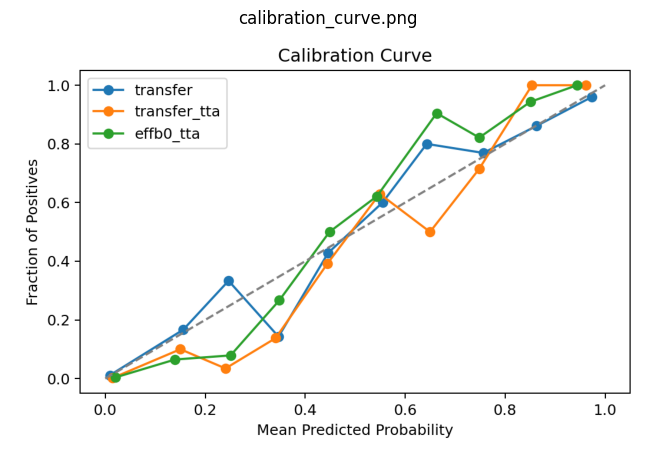

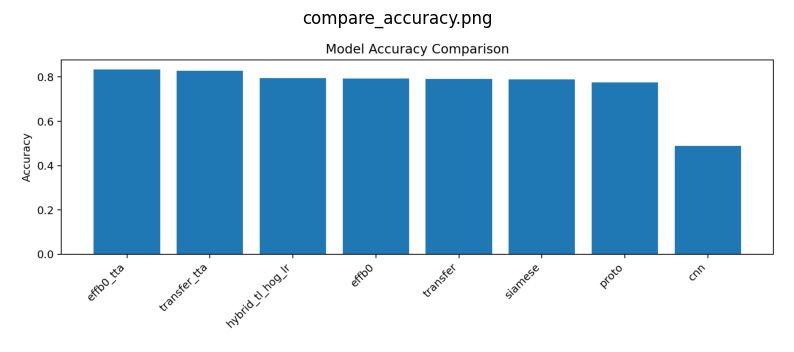

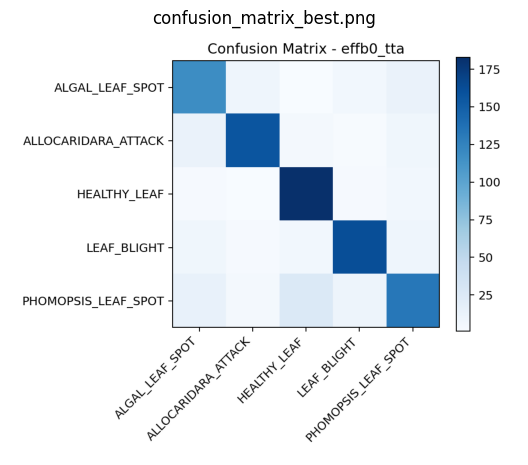

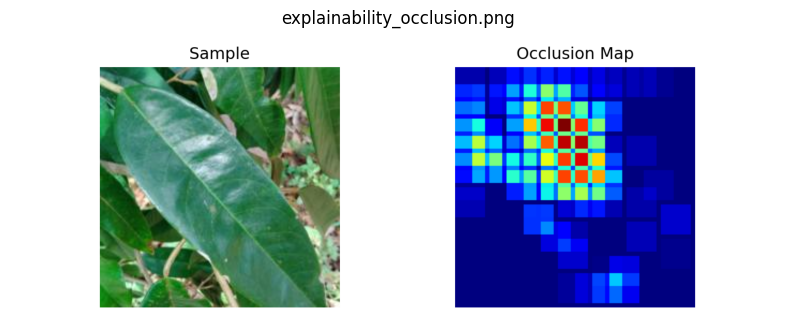

### Artifact Checklist

,artifact_path,category,status
0,./artifacts/runs/20260308T024003Z_aaae6380/run...,required,ok
1,./artifacts/runs/20260308T024003Z_aaae6380/met...,required,ok
2,./artifacts/runs/20260308T024003Z_aaae6380/tab...,required,ok
3,./artifacts/runs/20260308T024003Z_aaae6380/tab...,required,ok
4,./artifacts/runs/20260308T024003Z_aaae6380/tab...,required,ok
5,./artifacts/runs/20260308T024003Z_aaae6380/tab...,required,ok
6,./artifacts/runs/20260308T024003Z_aaae6380/tab...,required,ok
7,./artifacts/runs/20260308T024003Z_aaae6380/tab...,required,ok
8,./artifacts/runs/20260308T024003Z_aaae6380/fig...,required,ok
9,./artifacts/runs/20260308T024003Z_aaae6380/fig...,required,ok


**Runs root:** artifacts/runs

In [14]:
# [CRISP-DM: Evaluation - Run Gallery Viewer] [SAFE-RERUN]
# Menampilkan grafik-grafik hasil run terbaru, sekaligus memastikan folder artifacts/runs tersedia.
import os, glob
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

run_dir = globals().get('RUN_DIR', None)
if run_dir is None:
    base = Path('./artifacts/runs')
    base.mkdir(parents=True, exist_ok=True)
    runs = sorted([p for p in base.glob('*') if p.is_dir()])
    run_dir = str(runs[-1]) if runs else str(base)

run_path = Path(run_dir)
if run_path.name != 'runs' and run_path.parent.name == 'runs':
    runs_root = run_path.parent
else:
    runs_root = run_path if run_path.name == 'runs' else Path('./artifacts/runs')
    runs_root.mkdir(parents=True, exist_ok=True)

if run_path.name == 'runs':
    all_runs = sorted([p for p in run_path.glob('*') if p.is_dir()])
    if not all_runs:
        display(Markdown('**Folder rtifacts/runs sudah ada, tapi belum ada run di dalamnya.**'))
    else:
        run_path = all_runs[-1]

display(Markdown(f'**Run aktif:** {run_path}'))
if not run_path.exists():
    display(Markdown('**Path run tidak ditemukan di runtime ini.** Cek mount Google Drive / path kerja notebook.'))
else:
    fig_patterns = ['figures/*.png','figures/*.jpg','figures/*.jpeg','figures/*.svg']
    fig_files = []
    for pat in fig_patterns:
        fig_files.extend(sorted(run_path.glob(pat)))

    if not fig_files:
        display(Markdown('Tidak ada file gambar di folder igures/.'))
    else:
        display(Markdown(f'### Gallery ({len(fig_files)} figure files)'))
        for fp in fig_files:
            try:
                if fp.suffix.lower() == '.svg':
                    display(Markdown(f'- {fp.name} (SVG, buka file langsung jika tidak tampil inline)'))
                    continue
                img = plt.imread(str(fp))
                plt.figure(figsize=(10, 5.5))
                plt.imshow(img)
                plt.axis('off')
                plt.title(fp.name)
                plt.show()
            except Exception as e:
                display(Markdown(f'- Gagal render {fp.name}: {e}'))

    checklist_csv = run_path / 'tables' / 'artifact_checklist.csv'
    if checklist_csv.exists():
        import pandas as pd
        chk = pd.read_csv(checklist_csv)
        display(Markdown('### Artifact Checklist'))
        display(chk)

    display(Markdown(f'**Runs root:** {runs_root}'))


In [15]:
# [CRISP-DM: Evaluation - Advanced Metrics Extension] [SAFE-RERUN]
# Tujuan: menambah uji metrik yang belum eksplisit di evaluasi inti.
t0 = stage_start('eval_advanced_metrics') if 'stage_start' in globals() else None

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_recall_fscore_support, balanced_accuracy_score, accuracy_score,
    matthews_corrcoef, cohen_kappa_score, log_loss, confusion_matrix,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

if 'PRED_STORE' not in globals() or len(PRED_STORE) == 0:
    if t0 is not None and 'stage_end' in globals():
        stage_end('eval_advanced_metrics', t0, 'failed', 'PRED_STORE kosong')
    raise ValueError('PRED_STORE kosong. Jalankan sel Evaluation - Core + TTA + Significance terlebih dahulu.')

classes = np.arange(NUM_CLASSES) if 'NUM_CLASSES' in globals() else np.unique(next(iter(PRED_STORE.values()))['y_true'])
adv_rows = []
per_class_rows = []

def macro_specificity(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    specs = []
    for i in range(len(labels)):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        den = (tn + fp)
        specs.append(float(tn / den) if den > 0 else np.nan)
    vals = np.array(specs, dtype=float)
    return float(np.nanmean(vals)), specs

for key, pack in PRED_STORE.items():
    y_true = np.asarray(pack['y_true'])
    y_pred = np.asarray(pack['y_pred'])
    y_prob = None if pack.get('y_prob', None) is None else np.asarray(pack['y_prob'])

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    p_micro, r_micro, f1_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    spec_macro, spec_list = macro_specificity(y_true, y_pred, classes)

    row = {
        'model_key': key,
        'n_test': int(len(y_true)),
        'accuracy': float(acc),
        'balanced_accuracy': float(bal_acc),
        'macro_precision': float(p_macro),
        'macro_recall': float(r_macro),
        'macro_f1': float(f1_macro),
        'weighted_precision': float(p_weight),
        'weighted_recall': float(r_weight),
        'weighted_f1': float(f1_weight),
        'micro_precision': float(p_micro),
        'micro_recall': float(r_micro),
        'micro_f1': float(f1_micro),
        'mcc': float(mcc),
        'cohen_kappa': float(kappa),
        'macro_specificity': float(spec_macro),
        'top2_accuracy': np.nan,
        'log_loss': np.nan,
        'roc_auc_ovr_macro': np.nan,
        'pr_auc_ovr_macro': np.nan
    }

    for ci, c in enumerate(classes):
        tp = int(np.sum((y_true == c) & (y_pred == c)))
        fn = int(np.sum((y_true == c) & (y_pred != c)))
        fp = int(np.sum((y_true != c) & (y_pred == c)))
        tn = int(np.sum((y_true != c) & (y_pred != c)))
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        per_class_rows.append({
            'model_key': key,
            'class_index': int(c),
            'support': int(np.sum(y_true == c)),
            'sensitivity_recall': float(sens) if not np.isnan(sens) else np.nan,
            'specificity': float(spec) if not np.isnan(spec) else np.nan
        })

    if y_prob is not None and y_prob.ndim == 2 and y_prob.shape[0] == len(y_true):
        # top-2 accuracy
        top2 = np.argsort(y_prob, axis=1)[:, -2:]
        hit2 = np.any(top2 == y_true[:, None], axis=1)
        row['top2_accuracy'] = float(np.mean(hit2))

        # probabilistic metrics
        try:
            row['log_loss'] = float(log_loss(y_true, y_prob, labels=list(classes)))
        except Exception:
            row['log_loss'] = np.nan

        try:
            y_bin = label_binarize(y_true, classes=classes)
            if y_bin.shape[1] > 1:
                row['roc_auc_ovr_macro'] = float(roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr'))
                row['pr_auc_ovr_macro'] = float(average_precision_score(y_bin, y_prob, average='macro'))
        except Exception:
            pass

    adv_rows.append(row)

advanced_df = pd.DataFrame(adv_rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
per_class_df = pd.DataFrame(per_class_rows)

advanced_csv = os.path.join(DIRS['tables'], 'advanced_metrics.csv')
per_class_csv = os.path.join(DIRS['tables'], 'per_class_sensitivity_specificity.csv')
advanced_df.to_csv(advanced_csv, index=False)
per_class_df.to_csv(per_class_csv, index=False)
save_json(os.path.join(RUN_DIR, 'advanced_metrics.json'), advanced_df.to_dict(orient='records'))

if 'RUN_STATE' in globals():
    RUN_STATE.setdefault('artifacts', {})['advanced_metrics_csv'] = advanced_csv
    RUN_STATE['artifacts']['per_class_sensitivity_specificity_csv'] = per_class_csv
    for r in adv_rows:
        mk = r['model_key']
        RUN_STATE['metrics'].setdefault(mk, {})
        for k in ['weighted_f1','micro_f1','mcc','cohen_kappa','macro_specificity','top2_accuracy','log_loss','roc_auc_ovr_macro','pr_auc_ovr_macro']:
            RUN_STATE['metrics'][mk][k] = float(r[k]) if pd.notna(r[k]) else np.nan

print('Advanced metrics saved:')
print('-', advanced_csv)
print('-', per_class_csv)
display(advanced_df)

if t0 is not None and 'stage_end' in globals():
    stage_end('eval_advanced_metrics', t0, 'success')


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Advanced metrics saved:
- ./artifacts/runs/20260308T024003Z_aaae6380/tables/advanced_metrics.csv
- ./artifacts/runs/20260308T024003Z_aaae6380/tables/per_class_sensitivity_specificity.csv


,model_key,n_test,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,micro_precision,micro_recall,micro_f1,mcc,cohen_kappa,macro_specificity,top2_accuracy,log_loss,roc_auc_ovr_macro,pr_auc_ovr_macro
0,effb0_tta,902,0.834812,0.832518,0.832551,0.832518,0.831257,0.835747,0.834812,0.833959,0.834812,0.834812,0.834812,0.793760,0.793084,0.958765,0.943459,0.508019,0.971998,0.912370
1,transfer_tta,902,0.828160,0.827444,0.831946,0.827444,0.826013,0.837215,0.828160,0.829107,0.828160,0.828160,0.828160,0.786657,0.784978,0.957271,0.935698,0.480208,0.972519,0.918073
2,hybrid_tl_hog_lr,902,0.794900,0.792451,0.794114,0.792451,0.793062,0.795951,0.794900,0.795196,0.794900,0.794900,0.794900,0.743101,0.742992,0.948669,NaN,NaN,NaN,NaN
3,effb0,902,0.793792,0.791601,0.790262,0.791601,0.790393,0.793325,0.793792,0.793011,0.793792,0.793792,0.793792,0.741983,0.741718,0.948486,0.927938,0.559979,0.958067,0.878223
4,transfer,902,0.791574,0.791211,0.793641,0.791211,0.790054,0.798554,0.791574,0.792839,0.791574,0.791574,0.791574,0.740162,0.739225,0.948105,0.909091,0.586292,0.955729,0.875544
5,siamese,902,0.788248,0.784933,0.783766,0.784933,0.782800,0.788640,0.788248,0.786866,0.788248,0.788248,0.788248,0.735559,0.734833,0.947211,NaN,NaN,NaN,NaN
6,proto,902,0.776053,0.772650,0.774165,0.772650,0.772563,0.776952,0.776053,0.775610,0.776053,0.776053,0.776053,0.719789,0.719364,0.943992,NaN,NaN,NaN,NaN
7,cnn,902,0.488914,0.490393,0.496199,0.490393,0.487538,0.498391,0.488914,0.487792,0.488914,0.488914,0.488914,0.362403,0.360670,0.872188,0.749446,1.249535,0.798284,0.519335


In [16]:
# [CRISP-DM: Deployment - Export Streamlit Bundle (effb0_tta)] [SAFE-RERUN]
# Tujuan: simpan resource deploy khusus model terpilih effb0_tta ke artifacts Drive.
import os, json, shutil, numpy as np

# 1) Target artifacts root (sesuai permintaan)
ART_ROOT_CANDS = [
    '/content/gdrive/MyDrive/Colab Notebooks/widuri/artifacts',
    '/content/drive/MyDrive/Colab Notebooks/widuri/artifacts',
    './artifacts'
]
ART_ROOT = next((p for p in ART_ROOT_CANDS if os.path.isdir(os.path.dirname(p)) or p.startswith('./')), ART_ROOT_CANDS[-1])
os.makedirs(ART_ROOT, exist_ok=True)

# 2) Nama khusus bundle deploy
BUNDLE_NAME = 'effb0_tta'
BUNDLE_DIR = os.path.join(ART_ROOT, BUNDLE_NAME)
os.makedirs(BUNDLE_DIR, exist_ok=True)

# 3) Cari sumber model effb0 (base model untuk inferensi TTA)
src_keras = None
src_savedmodel = None
if 'DIRS' in globals() and isinstance(DIRS, dict) and 'models' in DIRS:
    cand_keras = os.path.join(DIRS['models'], 'effb0', 'model.keras')
    cand_sm = os.path.join(DIRS['models'], 'effb0', 'savedmodel')
    if os.path.isfile(cand_keras):
        src_keras = cand_keras
    if os.path.isdir(cand_sm):
        src_savedmodel = cand_sm

# fallback ke best artifacts jika best memang effb0_tta
if (src_keras is None or src_savedmodel is None) and ('RUN_STATE' in globals()) and isinstance(RUN_STATE, dict):
    best_name = (((RUN_STATE.get('best') or {}).get('model_key')) if isinstance(RUN_STATE.get('best'), dict) else None)
    if best_name in ['effb0_tta', 'effb0', 'effb0_opt_tta'] and 'DIRS' in globals() and 'best' in DIRS:
        best_keras = os.path.join(DIRS['best'], 'best_model.keras')
        best_sm = os.path.join(DIRS['best'], 'best_model_savedmodel')
        if src_keras is None and os.path.isfile(best_keras):
            src_keras = best_keras
        if src_savedmodel is None and os.path.isdir(best_sm):
            src_savedmodel = best_sm

# fallback dari objek model di memori
if src_keras is None and 'effb0_model' in globals():
    tmp_keras = os.path.join(BUNDLE_DIR, BUNDLE_NAME + '_model.keras')
    try:
        effb0_model.save(tmp_keras)
        src_keras = tmp_keras
    except Exception:
        pass
if src_savedmodel is None and 'effb0_model' in globals():
    tmp_sm = os.path.join(BUNDLE_DIR, BUNDLE_NAME + '_savedmodel_tmp')
    try:
        if os.path.isdir(tmp_sm):
            shutil.rmtree(tmp_sm)
        effb0_model.export(tmp_sm)
        src_savedmodel = tmp_sm
    except Exception:
        pass

if src_keras is None and src_savedmodel is None:
    raise FileNotFoundError('Model effb0 tidak ditemukan. Jalankan training/evaluasi effb0 terlebih dahulu.')

# 4) Copy model artifacts dengan nama pembeda effb0_tta
dst_keras = os.path.join(BUNDLE_DIR, BUNDLE_NAME + '_model.keras')
dst_savedmodel = os.path.join(BUNDLE_DIR, BUNDLE_NAME + '_savedmodel')
if src_keras is not None and os.path.isfile(src_keras):
    shutil.copy2(src_keras, dst_keras)
if src_savedmodel is not None and os.path.isdir(src_savedmodel):
    if os.path.isdir(dst_savedmodel):
        shutil.rmtree(dst_savedmodel)
    shutil.copytree(src_savedmodel, dst_savedmodel)

# 5) Simpan class names
class_arr = None
if 'class_names' in globals() and class_names is not None:
    class_arr = np.array(list(class_names), dtype=object)
elif 'CLASS_NAMES' in globals() and CLASS_NAMES is not None:
    class_arr = np.array(list(CLASS_NAMES), dtype=object)
elif 'DIRS' in globals() and 'best' in DIRS:
    best_cls = os.path.join(DIRS['best'], 'class_names.npy')
    if os.path.isfile(best_cls):
        class_arr = np.load(best_cls, allow_pickle=True)
if class_arr is None:
    raise FileNotFoundError('class_names tidak ditemukan.')
dst_classes = os.path.join(BUNDLE_DIR, BUNDLE_NAME + '_class_names.npy')
np.save(dst_classes, class_arr)

# 6) Ambil metrik effb0_tta dari metrics_long kalau ada
best_acc = None; macro_f1 = None; bal_acc = None
try:
    import pandas as pd
    mpath = os.path.join(DIRS['tables'], 'metrics_long.csv') if ('DIRS' in globals() and 'tables' in DIRS) else None
    if mpath and os.path.isfile(mpath):
        mdf = pd.read_csv(mpath)
        row = mdf.loc[mdf['model_key'] == 'effb0_tta']
        if len(row) > 0:
            best_acc = float(row.iloc[0]['test_accuracy'])
            if 'macro_f1' in row.columns: macro_f1 = float(row.iloc[0]['macro_f1'])
            if 'balanced_accuracy' in row.columns: bal_acc = float(row.iloc[0]['balanced_accuracy'])
except Exception:
    pass

# 7) Simpan metadata deploy khusus effb0_tta
meta = {
    'best_model_name': 'effb0_tta',
    'base_model_artifact_key': 'effb0',
    'deployment_policy': 'tta_identity_hflip_vflip_rot90_rot270_prob_avg',
    'tta_enabled': True,
    'tta_transforms': ['identity', 'flip_left_right', 'flip_up_down', 'rot90', 'rot270'],
    'img_size': [int(IMG_SIZE[0]), int(IMG_SIZE[1])] if 'IMG_SIZE' in globals() else [224,224],
    'num_classes': int(len(class_arr)),
    'best_model_accuracy': best_acc,
    'macro_f1': macro_f1,
    'balanced_accuracy': bal_acc,
    'model_keras_path': os.path.basename(dst_keras) if os.path.isfile(dst_keras) else None,
    'model_savedmodel_path': os.path.basename(dst_savedmodel) if os.path.isdir(dst_savedmodel) else None,
    'class_names_path': os.path.basename(dst_classes)
}
dst_meta = os.path.join(BUNDLE_DIR, BUNDLE_NAME + '_meta.json')
with open(dst_meta, 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

# 8) Manifest agar mudah dibaca app.py/streamlit
manifest = {
    'bundle_name': BUNDLE_NAME,
    'bundle_dir': BUNDLE_DIR,
    'files': {
        'keras': dst_keras if os.path.isfile(dst_keras) else None,
        'savedmodel': dst_savedmodel if os.path.isdir(dst_savedmodel) else None,
        'class_names': dst_classes,
        'meta': dst_meta
    }
}
dst_manifest = os.path.join(BUNDLE_DIR, BUNDLE_NAME + '_manifest.json')
with open(dst_manifest, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print('Export deploy bundle selesai:')
print('-', BUNDLE_DIR)
for k,v in manifest['files'].items():
    print(f'  {k}: {v}')


Export deploy bundle selesai:
- /content/gdrive/MyDrive/Colab Notebooks/widuri/artifacts/effb0_tta
  keras: /content/gdrive/MyDrive/Colab Notebooks/widuri/artifacts/effb0_tta/effb0_tta_model.keras
  savedmodel: /content/gdrive/MyDrive/Colab Notebooks/widuri/artifacts/effb0_tta/effb0_tta_savedmodel
  class_names: /content/gdrive/MyDrive/Colab Notebooks/widuri/artifacts/effb0_tta/effb0_tta_class_names.npy
  meta: /content/gdrive/MyDrive/Colab Notebooks/widuri/artifacts/effb0_tta/effb0_tta_meta.json


Saving duren loro3.jpg to duren loro3.jpg
File: duren loro3.jpg
Model        : effb0_tta
Test Accuracy: 0.8348115299334812


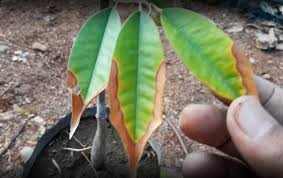

Predicted    : LEAF_BLIGHT
Confidence   : 0.4525

Top-5 probabilities:
- LEAF_BLIGHT : 0.452511
- PHOMOPSIS_LEAF_SPOT : 0.390015
- HEALTHY_LEAF : 0.135929
- ALLOCARIDARA_ATTACK : 0.016848
- ALGAL_LEAF_SPOT : 0.004698


In [21]:
# [CRISP-DM: Deployment - Manual Predict (effb0_tta)] [SAFE-RERUN]
# Prediksi kelas dari gambar input (upload manual di Colab) - FORCE effb0_tta (deployment final, GRACEFUL)
import os
import pathlib
import json
import numpy as np
import tensorflow as tf
from PIL import Image

IN_COLAB = 'google.colab' in str(getattr(__import__('sys'), 'modules', {}))
if IN_COLAB:
    from IPython.display import display
    from google.colab import files
else:
    print('Bukan runtime Colab. Sel upload manual dilewati tanpa error.')

MODEL_TO_USE = 'effb0_tta'


def _find_artifacts_root():
    candidates = []
    if 'DEPLOY_DIR' in globals() and isinstance(DEPLOY_DIR, str):
        candidates.append(DEPLOY_DIR)
    candidates.extend([
        '/content/gdrive/MyDrive/Colab Notebooks/widuri/artifacts',
        '/content/drive/MyDrive/Colab Notebooks/widuri/artifacts',
        './artifacts'
    ])
    seen = set()
    for c in candidates:
        if not c:
            continue
        c = str(c)
        if c in seen:
            continue
        seen.add(c)
        if os.path.isdir(c):
            return c
    return None


def _resolve_bundle_dir(art_root):
    if not art_root:
        return None
    bdir = os.path.join(art_root, 'effb0_tta')
    if os.path.isdir(bdir):
        return bdir
    return art_root  # fallback lama


def _load_labels_and_meta(bundle_dir):
    labels = None
    meta = None
    if bundle_dir:
        for lp in [
            os.path.join(bundle_dir, 'effb0_tta_class_names.npy'),
            os.path.join(bundle_dir, 'class_names.npy')
        ]:
            if os.path.exists(lp):
                try:
                    labels = np.load(lp, allow_pickle=True).tolist()
                    break
                except Exception:
                    pass
        for mp in [
            os.path.join(bundle_dir, 'effb0_tta_meta.json'),
            os.path.join(bundle_dir, 'meta.json')
        ]:
            if os.path.exists(mp):
                try:
                    with open(mp, 'r', encoding='utf-8') as f:
                        meta = json.load(f)
                    break
                except Exception:
                    pass
    return labels, meta


def _load_effb0_keras(bundle_dir):
    if not bundle_dir:
        return None, None
    for fname in [
        'effb0_tta_model.keras',
        'effb0_model.keras',
        'effb0.keras',
        'best_model.keras',
        'best_model.h5'
    ]:
        fp = os.path.join(bundle_dir, fname)
        if os.path.exists(fp):
            try:
                return tf.keras.models.load_model(fp, compile=False), fp
            except Exception:
                continue
    return None, None


def _load_savedmodel_infer(bundle_dir):
    if not bundle_dir:
        return None, None
    for export_dir in [
        os.path.join(bundle_dir, 'effb0_tta_savedmodel'),
        os.path.join(bundle_dir, 'effb0_savedmodel'),
        os.path.join(bundle_dir, 'best_model_savedmodel')
    ]:
        if not os.path.exists(export_dir):
            continue
        try:
            obj = tf.saved_model.load(export_dir)
            infer = obj.signatures['serving_default']
            return infer, export_dir
        except Exception:
            continue
    return None, None


def _infer_img_size(model=None, meta=None):
    if isinstance(meta, dict) and 'img_size' in meta:
        try:
            h, w = meta['img_size']
            return (int(h), int(w))
        except Exception:
            pass
    if model is not None:
        try:
            shp = model.input_shape
            if isinstance(shp, list):
                shp = shp[0]
            return (int(shp[1]), int(shp[2]))
        except Exception:
            pass
    if 'IMG_SIZE' in globals() and isinstance(IMG_SIZE, (list, tuple)) and len(IMG_SIZE) == 2:
        return (int(IMG_SIZE[0]), int(IMG_SIZE[1]))
    return (224, 224)


def _tta_views(x, meta):
    transforms = ['identity']
    if isinstance(meta, dict) and meta.get('tta_enabled', True):
        transforms = meta.get('tta_transforms', ['identity', 'flip_left_right', 'flip_up_down', 'rot90', 'rot270'])
    views = []
    for t in transforms:
        if t == 'identity':
            views.append(x)
        elif t in ['flip_left_right', 'hflip']:
            views.append(np.flip(x, axis=2))
        elif t in ['flip_up_down', 'vflip']:
            views.append(np.flip(x, axis=1))
        elif t == 'rot90':
            views.append(np.rot90(x, 1, axes=(1,2)).copy())
        elif t == 'rot270':
            views.append(np.rot90(x, 3, axes=(1,2)).copy())
    return views if len(views) > 0 else [x]


if IN_COLAB:
    art_root = _find_artifacts_root()
    bundle_dir = _resolve_bundle_dir(art_root)
    labels_art, meta_art = _load_labels_and_meta(bundle_dir)

    keras_model = globals().get('effb0_model', None)
    keras_path = None
    if keras_model is None:
        keras_model, keras_path = _load_effb0_keras(bundle_dir)
        if keras_model is not None:
            print('Auto-loaded EffB0 (Keras) dari bundle:', keras_path)

    infer_fn = None
    savedmodel_path = None
    if keras_model is None:
        infer_fn, savedmodel_path = _load_savedmodel_infer(bundle_dir)
        if infer_fn is not None:
            print('Fallback ke SavedModel infer dari bundle:', savedmodel_path)

    if labels_art is not None and ('class_names' not in globals() or not globals().get('class_names')):
        class_names = list(labels_art)

    if 'class_names' not in globals() or not class_names:
        print('Tidak bisa prediksi: class_names tidak tersedia (bundle class_names.npy tidak ditemukan).')
    elif keras_model is None and infer_fn is None:
        print('Tidak bisa prediksi: model effb0 tidak tersedia di memori, file .keras, maupun SavedModel.')
        print('Pastikan folder bundle berisi effb0_tta_model.keras atau effb0_tta_savedmodel.')
    else:
        uploaded = files.upload()
        if len(uploaded) == 0:
            print('Tidak ada file yang diupload.')
        else:
            img_name = list(uploaded.keys())[0]
            print('File:', img_name)
            print('Model        :', MODEL_TO_USE)
            if isinstance(meta_art, dict):
                print('Test Accuracy:', meta_art.get('best_model_accuracy', None))
            img = tf.keras.utils.load_img(img_name, target_size=_infer_img_size(model=keras_model, meta=meta_art))
            img_arr = tf.keras.utils.img_to_array(img).astype('float32') / 255.0
            x = np.expand_dims(img_arr, axis=0)
            display(Image.open(img_name))

            views = _tta_views(x, meta_art)
            if keras_model is not None:
                probs_list = [keras_model.predict(v, verbose=0)[0] for v in views]
            else:
                probs_list = []
                for v in views:
                    out = infer_fn(tf.convert_to_tensor(v, dtype=tf.float32))
                    probs_list.append(list(out.values())[0].numpy()[0])
            probs = np.mean(np.stack(probs_list, axis=0), axis=0)

            pred_idx = int(np.argmax(probs))
            conf = float(probs[pred_idx])
            print('Predicted    :', class_names[pred_idx])
            print('Confidence   :', round(conf, 4))

            topk = np.argsort(probs)[::-1][:5]
            print('\nTop-5 probabilities:')
            for i in topk:
                print('-', class_names[i], ':', round(float(probs[i]), 6))
